In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/salesdaily.csv")

df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [9]:
df_long = df.melt(
    id_vars=['datum'],
    value_vars=['M01AB','M01AE','N02BA','N02BE','N05B','N05C','R03','R06'],
    var_name='ATC',
    value_name='quantity'
)

df_long.head()

,datum,ATC,quantity
0,2014-01-02,M01AB,0.0
1,2014-01-03,M01AB,8.0
2,2014-01-04,M01AB,2.0
3,2014-01-05,M01AB,4.0
4,2014-01-06,M01AB,5.0


In [10]:
df_long['datum'] = pd.to_datetime(df_long['datum'])
df_long['year'] = df_long['datum'].dt.year
df_long['month'] = df_long['datum'].dt.month

Total Sales QTY per Drug Category (ATC)

ATC
N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
Name: quantity, dtype: float64


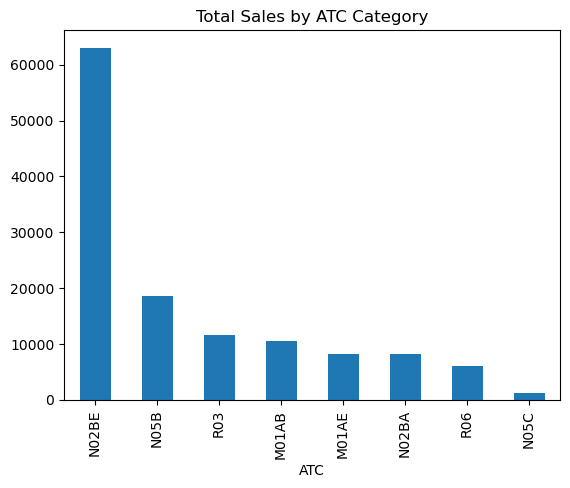

In [13]:
atc_sales = df_long.groupby('ATC')['quantity'].sum().sort_values(ascending=False)
print(atc_sales)

atc_sales.plot(kind='bar')
plt.title("Total Sales by ATC Category")
plt.show()

Drug that have highest total sales

ATC
N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
Name: quantity, dtype: float64


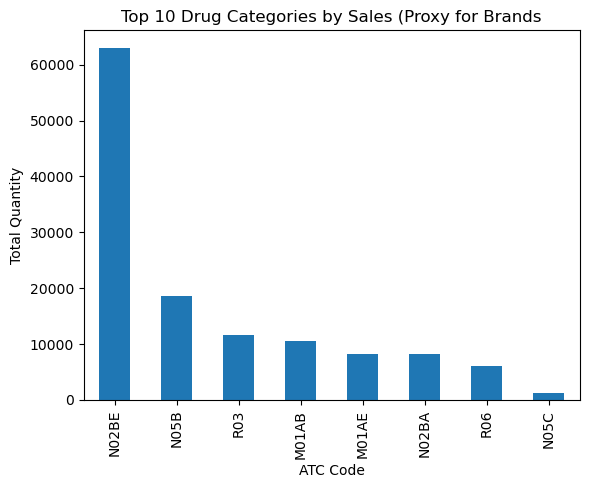

In [16]:
brand_like_sales = df_long.groupby('ATC')['quantity'].sum().sort_values(ascending=False)

print(brand_like_sales.head(10))


brand_like_sales.head(10).plot(kind='bar')
plt.title("Top 10 Drug Categories by Sales (Proxy for Brands")
plt.xlabel("ATC Code")
plt.ylabel("Total Quantity")
plt.show()

Three Drugs that have the Highest Sales in January 2015, July 2016, September 2017

In [19]:
def top_atc_by_month(year, month):
    filtered = df_long[
        (df_long['year'] == year) &
        (df_long['month'] == month)
    ]

    return filtered.groupby('ATC')['quantity'].sum().sort_values(ascending=False)

In [20]:
print("January 2015:\n", top_atc_by_month(2015, 1))
print("July 2016:\n", top_atc_by_month(2016,7))
print("July2017:\n", top_atc_by_month(2017,9))

January 2015:
 ATC
N02BE    1044.240
N05B      463.000
R03       177.250
N02BA     141.000
M01AB     135.910
M01AE     130.349
R06        42.000
N05C       24.000
Name: quantity, dtype: float64
July 2016:
 ATC
N02BE    652.362000
N05B     240.000000
M01AB    194.528333
M01AE    141.019000
N02BA    137.900000
R06      116.830000
R03      109.000000
N05C       8.000000
Name: quantity, dtype: float64
July2017:
 ATC
N02BE    863.750
N05B     223.000
R03      139.000
M01AB    138.330
M01AE    118.711
N02BA     88.150
R06       66.900
N05C      23.000
Name: quantity, dtype: float64


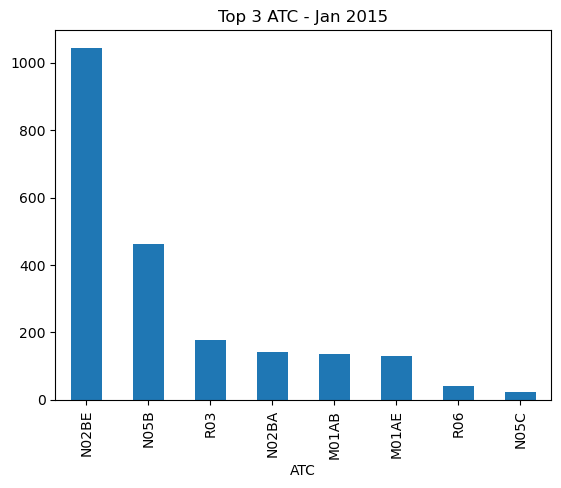

In [21]:
top_atc_by_month(2015, 1).plot(kind='bar')
plt.title("Top 3 ATC - Jan 2015")
plt.show()

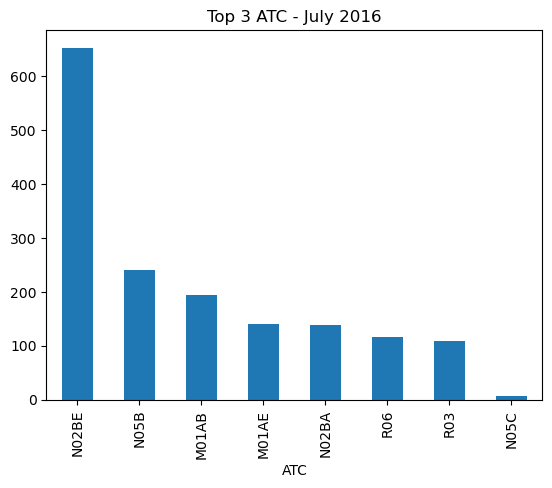

In [22]:
top_atc_by_month(2016, 7).plot(kind='bar')
plt.title("Top 3 ATC - July 2016")
plt.show()

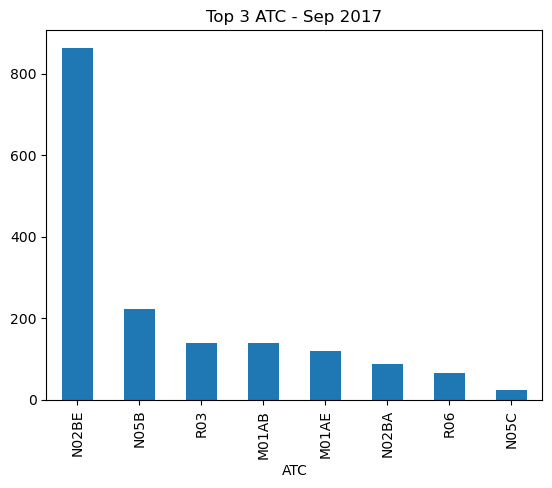

In [23]:
top_atc_by_month(2017, 9).plot(kind='bar')
plt.title("Top 3 ATC - Sep 2017")
plt.show()

Top Sales at 2017

In [25]:
sales_2017 = df_long[df_long['year'] == 2017]

top_2017 = sales_2017.groupby('ATC')['quantity'].sum().sort_values(ascending=False)

print(top_2017.head(1))

ATC
N02BE    9258.804833
Name: quantity, dtype: float64


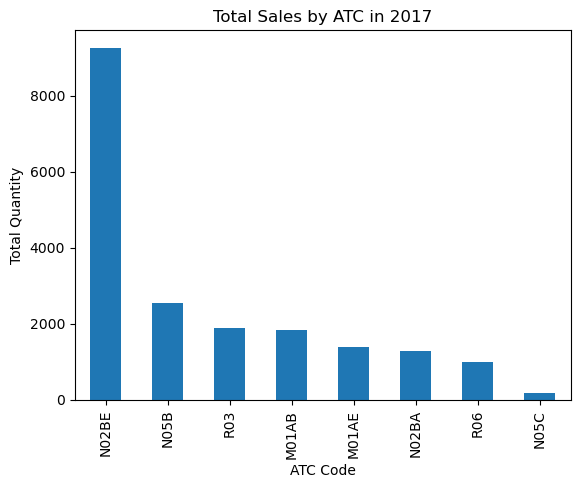

In [26]:
top_2017.plot(kind='bar')
plt.title("Total Sales by ATC in 2017")
plt.xlabel("ATC Code")
plt.ylabel("Total Quantity")
plt.show()

highest AVG daily sales

In [33]:
daily_sales = df_long.groupby(['datum','ATC'])['quantity'].sum().reset_index()

avg_sales = daily_sales.groupby('ATC')['quantity'].mean().sort_values(ascending=False)

print(avg_sales.head(1))

ATC
N02BE    29.917095
Name: quantity, dtype: float64


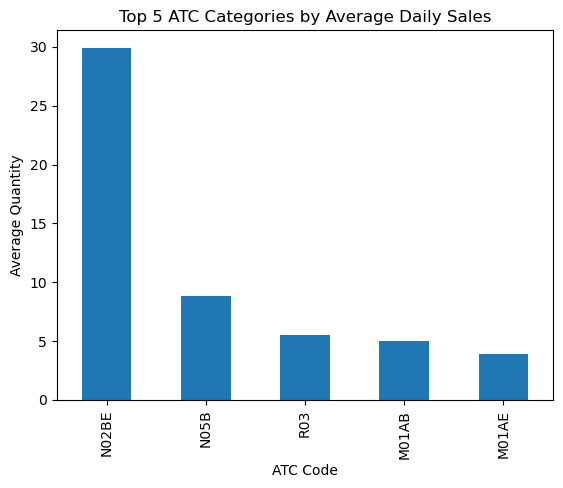

In [34]:
avg_sales.head(5).plot(kind='bar')

plt.title("Top 5 ATC Categories by Average Daily Sales")
plt.xlabel("ATC Code")
plt.ylabel("Average Quantity")
plt.show()

Are respiratory drugs (R03) sold more during specific months?

In [35]:
r03 = df_long[df_long['ATC'] == 'R03']

In [38]:
monthly_r03 = r03.groupby('month')['quantity'].mean()
monthly_r03 = monthly_r03.sort_index()
print(monthly_r03)

month
1     6.835980
2     6.896943
3     6.290323
4     5.771528
5     5.006944
6     4.350000
7     2.956989
8     3.102151
9     4.402315
10    7.208589
11    6.226667
12    7.916129
Name: quantity, dtype: float64


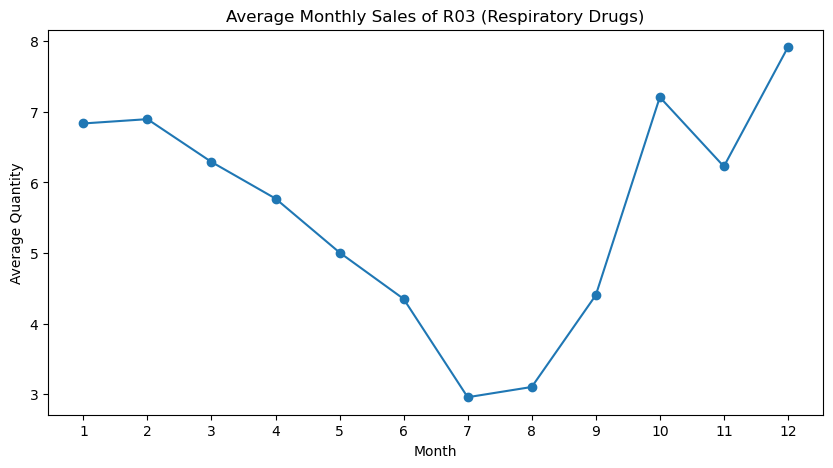

In [39]:
plt.figure(figsize=(10,5))

monthly_r03.plot(kind='line', marker='o')

plt.title("Average Monthly Sales of R03 (Respiratory Drugs)")
plt.xlabel("Month")
plt.ylabel("Average Quantity")
plt.xticks(range(1,13))
plt.show()